In [2]:
import pandas as pd
df=pd.read_csv("data/DB_final.csv")

In [57]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(X_test, y_test, model, class_names):
    y_pred = model.predict(X_test)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))

    plt.figure(figsize=(12, 8))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Model Builder Detection - Confusion Matrix')
    plt.show()

    importances = model.feature_importances_
    feature_names = X_test.columns


    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)


    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis',hue="Importance")

    plt.title('Influential Features (Linguistic Fingerprints)')
    plt.xlabel('Importance Score (Gain)')
    plt.ylabel('Features')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

# Model predation Task Based on Text Length

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


if df.isnull().sum().sum() > 0:
    raise ValueError(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")


y = df['Writer']


y_le = LabelEncoder()                                        
y_encoded = y_le.fit_transform(y)


_, X_test, _, y_test= train_test_split(
    df, 
    y_encoded, 
    test_size=0.20, 
    random_state=999, 
    stratify=y_encoded   # same class distribution in train and test
)
y_test_series = pd.Series(y_test, index=X_test.index)

In [25]:
X_LEN=X_test["Text"].apply(len)
def IQR_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return outliers
outliers = IQR_outliers(X_LEN)
(X_LEN.drop(outliers.index)).describe()

count    9503.000000
mean     2828.755972
std       775.042466
min       526.000000
25%      2268.000000
50%      2703.000000
75%      3317.000000
max      5101.000000
Name: Text, dtype: float64

In [26]:
SHORT, MEDIUM,LONG=2268, 3317,float('inf')
df_short = X_test[X_LEN <= SHORT]
df_medium = X_test[(X_LEN > SHORT) & (X_LEN <= MEDIUM)]
df_long = X_test[X_LEN > MEDIUM]
df_short.shape, df_medium.shape, df_long.shape

((2736, 19), (4751, 19), (2750, 19))

## Model Evaluation 

In [ ]:
import joblib
xgb_classifier = joblib.load("models/xgb_classifier_model.pkl")

### short

Short Texts Evaluation:

Classification Report:
                                   precision    recall  f1-score   support

                          GPT_4-o       0.69      0.97      0.81        61
                      Human_story       0.96      0.95      0.95       644
accounts/yi-01-ai/models/yi-large       0.41      0.33      0.37        58
                       gemma-2-9b       0.79      0.85      0.82       757
                         llama-8B       0.47      0.46      0.47       102
                       mistral-7B       0.56      0.55      0.56       437
                       qwen-2-72B       0.81      0.74      0.77       677

                         accuracy                           0.77      2736
                        macro avg       0.67      0.69      0.68      2736
                     weighted avg       0.77      0.77      0.77      2736



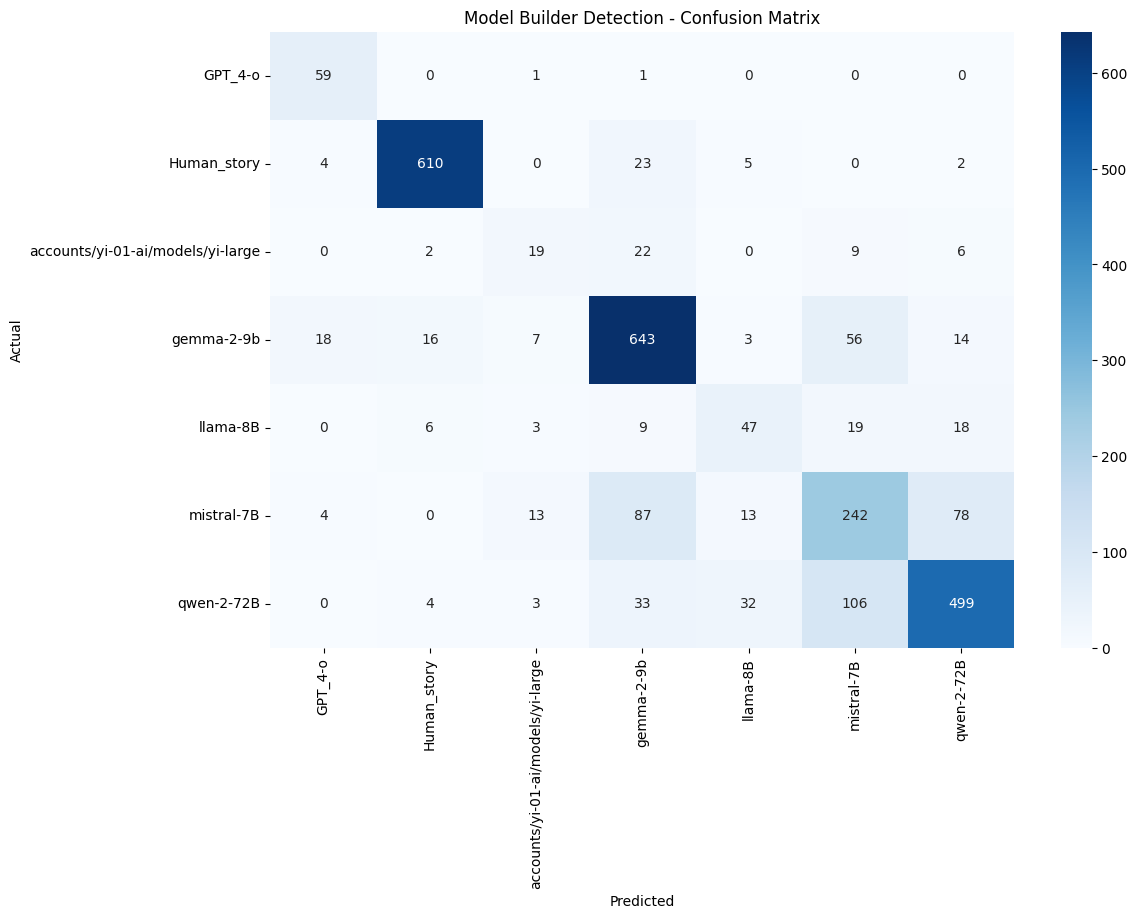

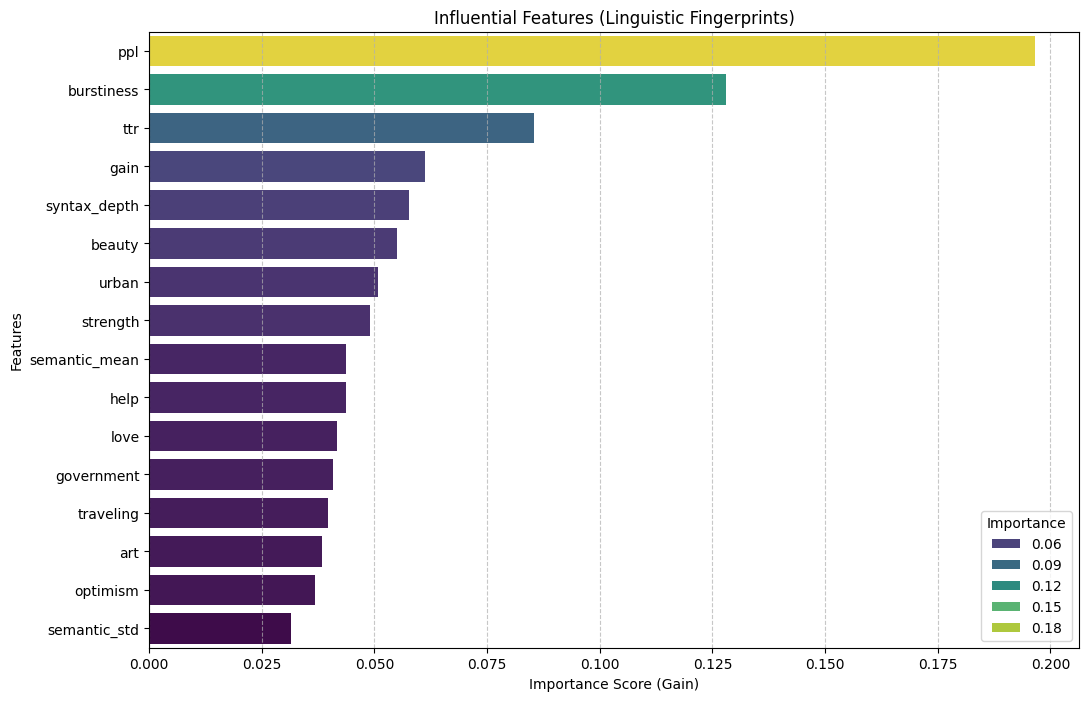

In [ ]:
print("Short Texts Evaluation:")

evaluate_model(
    df_short.drop(columns=['Text', 'Writer','is_AI']),
    y_test_series.loc[df_short.index],
    xgb_classifier,
    y_le.classes_
)

### medium

Medium Texts Evaluation:

Classification Report:
                                   precision    recall  f1-score   support

                          GPT_4-o       0.31      0.49      0.38        75
                      Human_story       0.85      0.94      0.89       279
accounts/yi-01-ai/models/yi-large       0.71      0.74      0.73       938
                       gemma-2-9b       0.78      0.79      0.79       684
                         llama-8B       0.62      0.61      0.61      1149
                       mistral-7B       0.51      0.46      0.49       936
                       qwen-2-72B       0.54      0.54      0.54       690

                         accuracy                           0.64      4751
                        macro avg       0.62      0.65      0.63      4751
                     weighted avg       0.64      0.64      0.64      4751



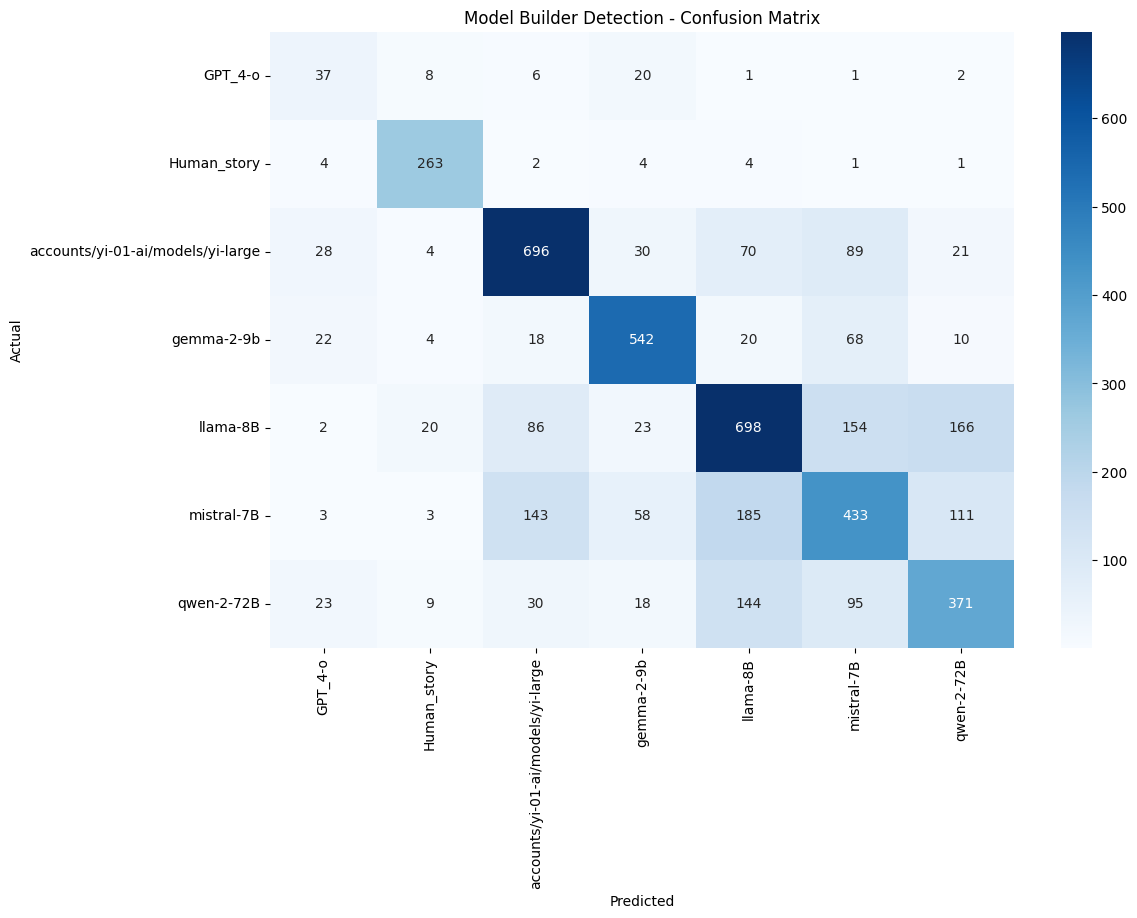

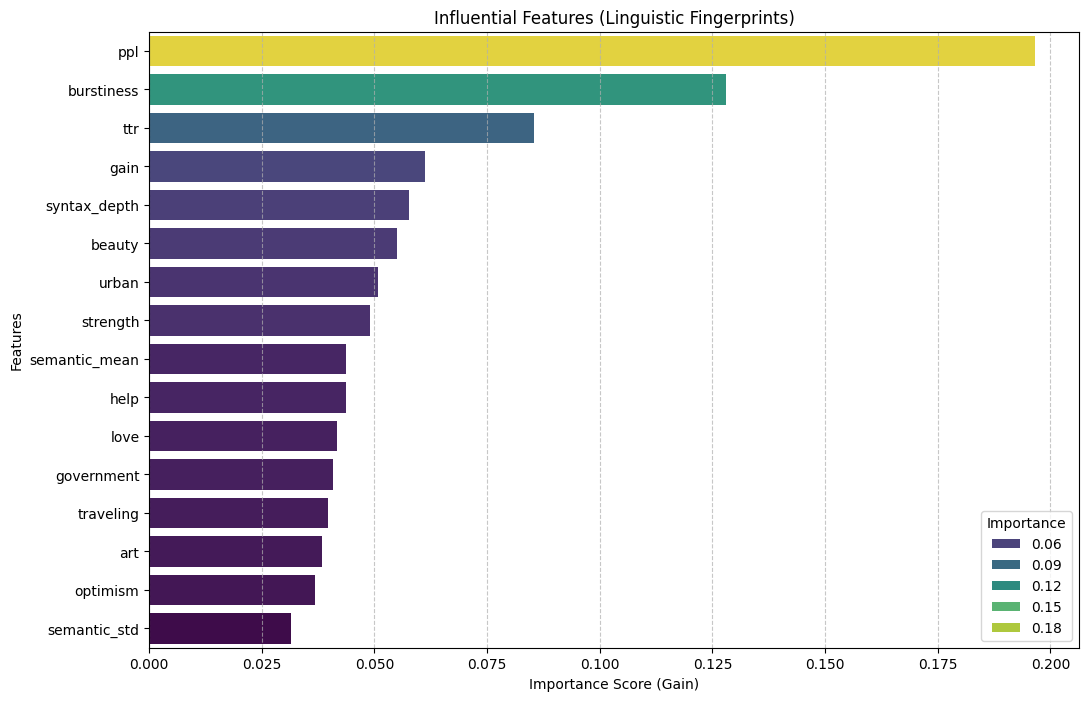

In [ ]:
print("Medium Texts Evaluation:")
evaluate_model(
    df_medium.drop(columns=['Text', 'Writer','is_AI']),
    y_test_series.loc[df_medium.index],
    xgb_classifier,
    y_le.classes_
)

### Long

Long Texts Evaluation:

Classification Report:
                                   precision    recall  f1-score   support

                          GPT_4-o       0.92      0.87      0.90      1329
                      Human_story       0.96      0.93      0.95       536
accounts/yi-01-ai/models/yi-large       0.72      0.76      0.74       468
                       gemma-2-9b       0.20      0.48      0.28        21
                         llama-8B       0.53      0.66      0.59       210
                       mistral-7B       0.23      0.26      0.24        90
                       qwen-2-72B       0.36      0.24      0.29        96

                         accuracy                           0.81      2750
                        macro avg       0.56      0.60      0.57      2750
                     weighted avg       0.82      0.81      0.81      2750



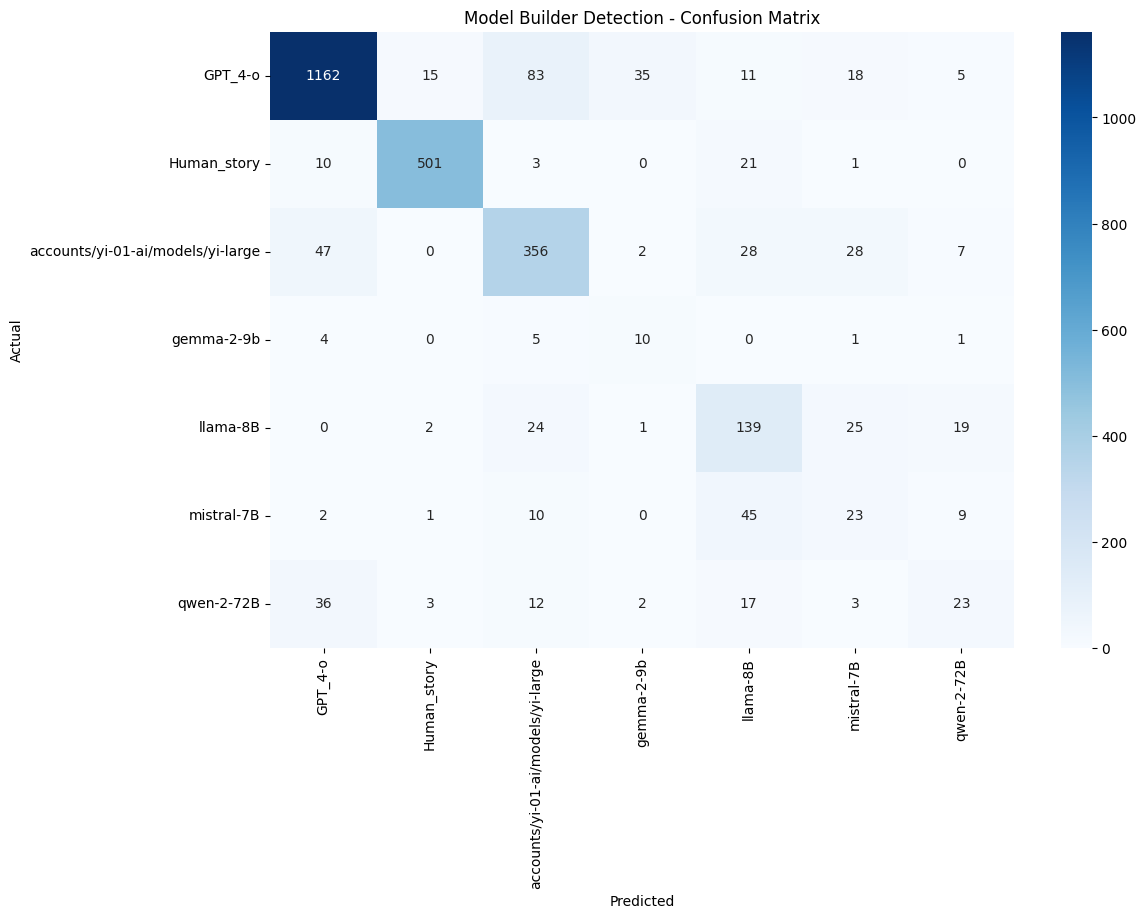

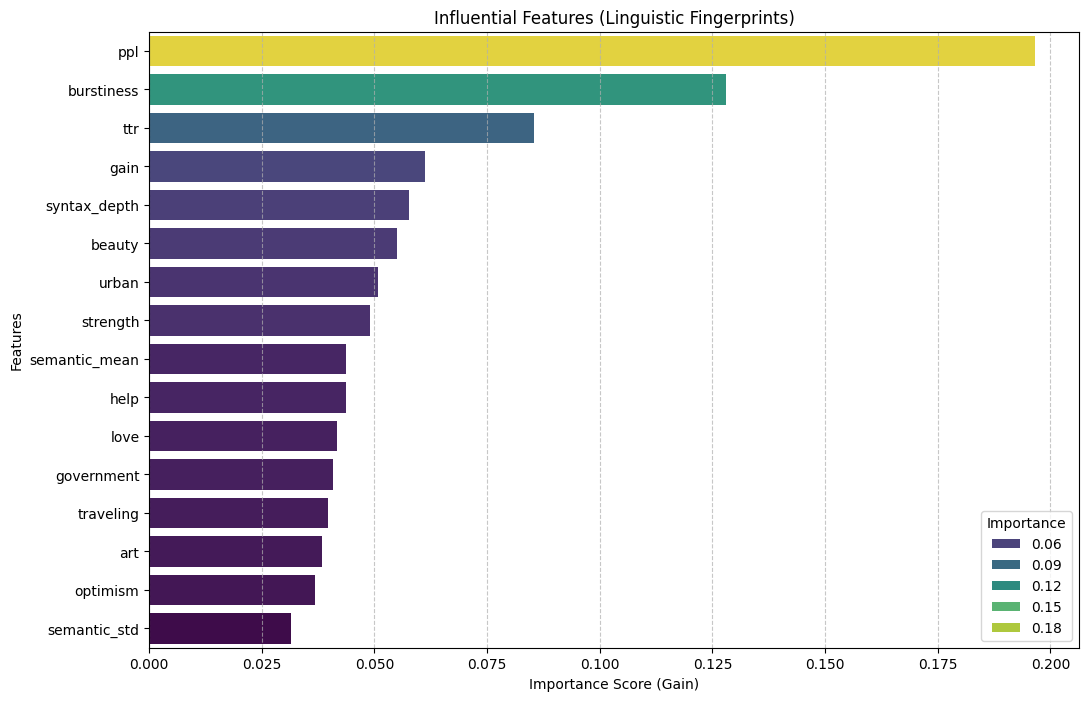

In [ ]:
print("Long Texts Evaluation:")
evaluate_model(
    df_long.drop(columns=['Text', 'Writer','is_AI']),
    y_test_series.loc[df_long.index],
    xgb_classifier,
    y_le.classes_
)

# AI Detection Task Based on Text Length

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

if df.isnull().sum().sum() > 0:
    raise ValueError(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

z = df['is_AI']


_, X_test, _, z_test= train_test_split(
    df, 
    z, 
    test_size=0.20, 
    random_state=999, 
    stratify=z           # same class distribution in train and test
)

z_test_series = pd.Series(z_test, index=X_test.index)

In [48]:
X_LEN=X_test["Text"].apply(len)
def IQR_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return outliers
outliers = IQR_outliers(X_LEN)
(X_LEN.drop(outliers.index)).describe()

count    9519.000000
mean     2830.500263
std       783.747620
min       502.000000
25%      2268.000000
50%      2698.000000
75%      3328.000000
max      5136.000000
Name: Text, dtype: float64

In [49]:
SHORT, MEDIUM,LONG=2268, 3328,float('inf')
df_short = X_test[X_LEN <= SHORT]
df_medium = X_test[(X_LEN > SHORT) & (X_LEN <= MEDIUM)]
df_long = X_test[X_LEN > MEDIUM]
df_short.shape, df_medium.shape, df_long.shape

((2731, 19), (4754, 19), (2752, 19))

## Model Evaluation 

In [50]:
import joblib

xgb_is_ai_model = joblib.load("models/xgb_is_ai_model.pkl")

### short

Short Texts Evaluation: 

Classification Report:
              precision    recall  f1-score   support

       Human       0.97      0.96      0.96       668
          AI       0.99      0.99      0.99      2063

    accuracy                           0.98      2731
   macro avg       0.98      0.97      0.98      2731
weighted avg       0.98      0.98      0.98      2731



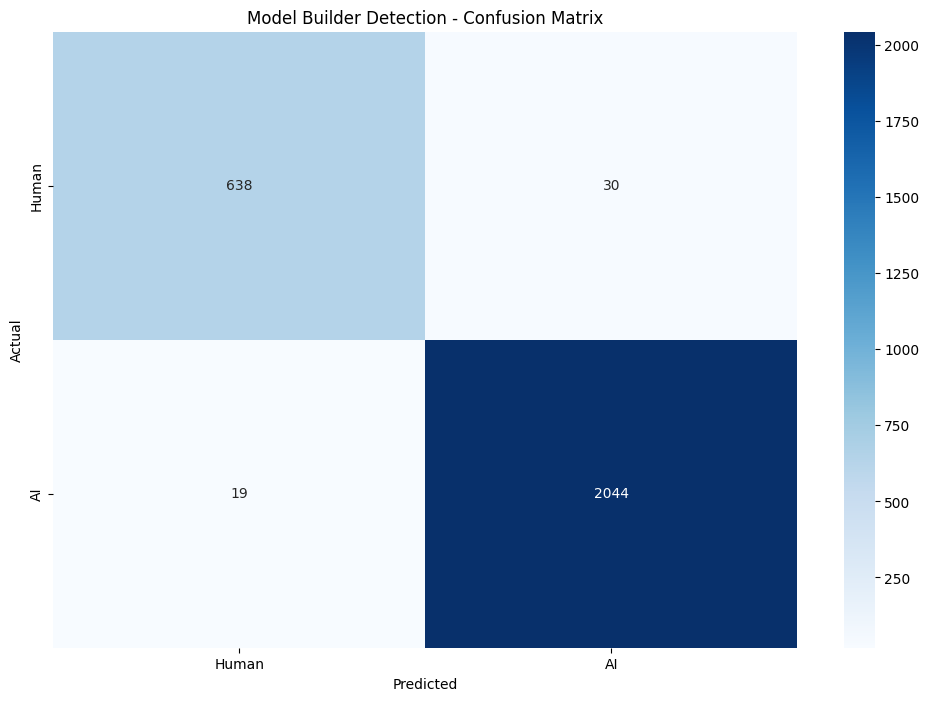

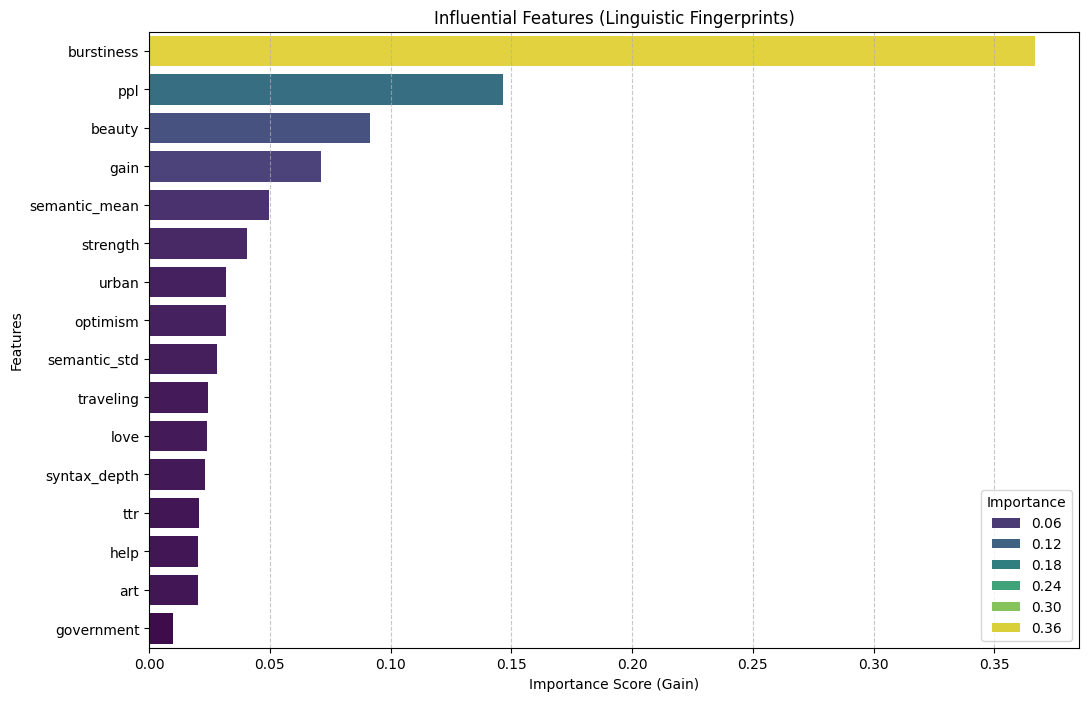

In [ ]:
print("Short Texts Evaluation: ")
evaluate_model(
    df_short.drop(columns=['Text', 'Writer','is_AI']),
    z_test_series.loc[df_short.index],
    xgb_is_ai_model,
    ['Human', 'AI']
)

### medium

Medium Texts Evaluation:

Classification Report:
              precision    recall  f1-score   support

       Human       0.91      0.91      0.91       256
          AI       0.99      0.99      0.99      4498

    accuracy                           0.99      4754
   macro avg       0.95      0.95      0.95      4754
weighted avg       0.99      0.99      0.99      4754



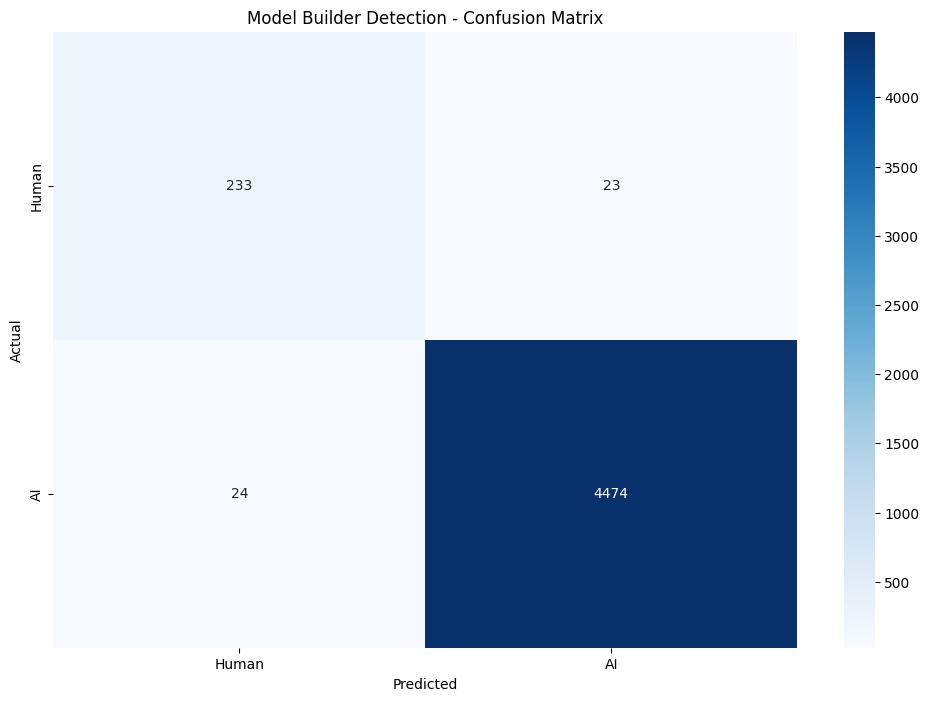

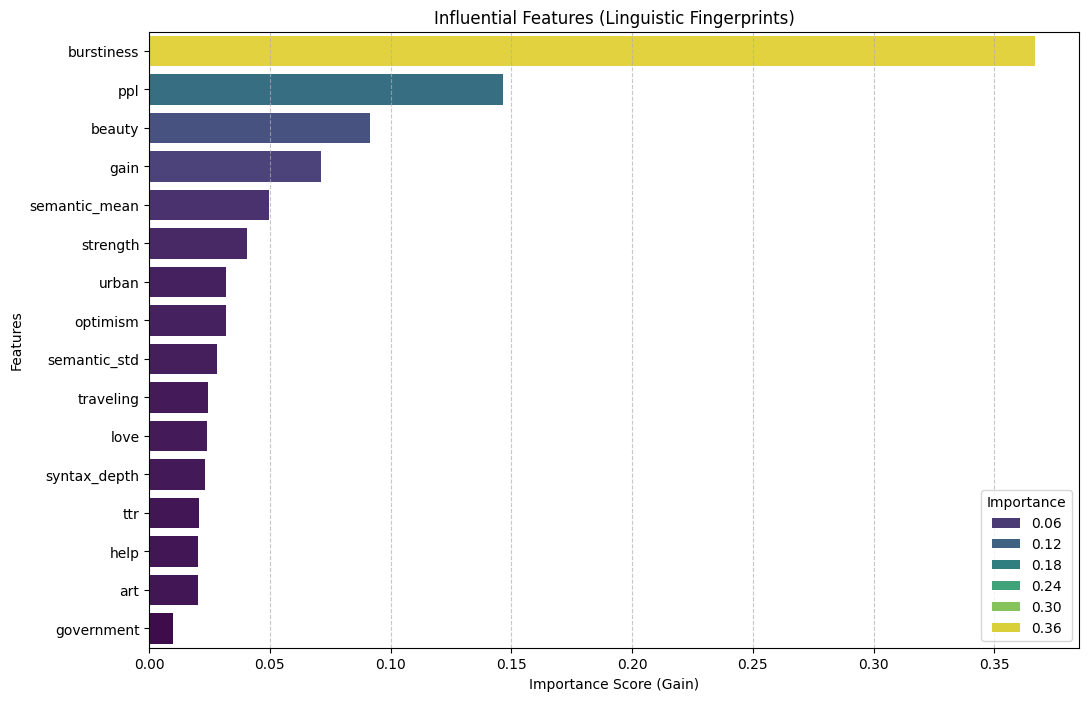

In [ ]:
print("Medium Texts Evaluation:")
evaluate_model(
    df_medium.drop(columns=['Text', 'Writer','is_AI']),
    z_test_series.loc[df_medium.index],
    xgb_is_ai_model,
    ['Human', 'AI']
)

### Long

Long Texts Evaluation:

Classification Report:
              precision    recall  f1-score   support

       Human       0.97      0.90      0.93       535
          AI       0.98      0.99      0.98      2217

    accuracy                           0.97      2752
   macro avg       0.97      0.94      0.96      2752
weighted avg       0.97      0.97      0.97      2752



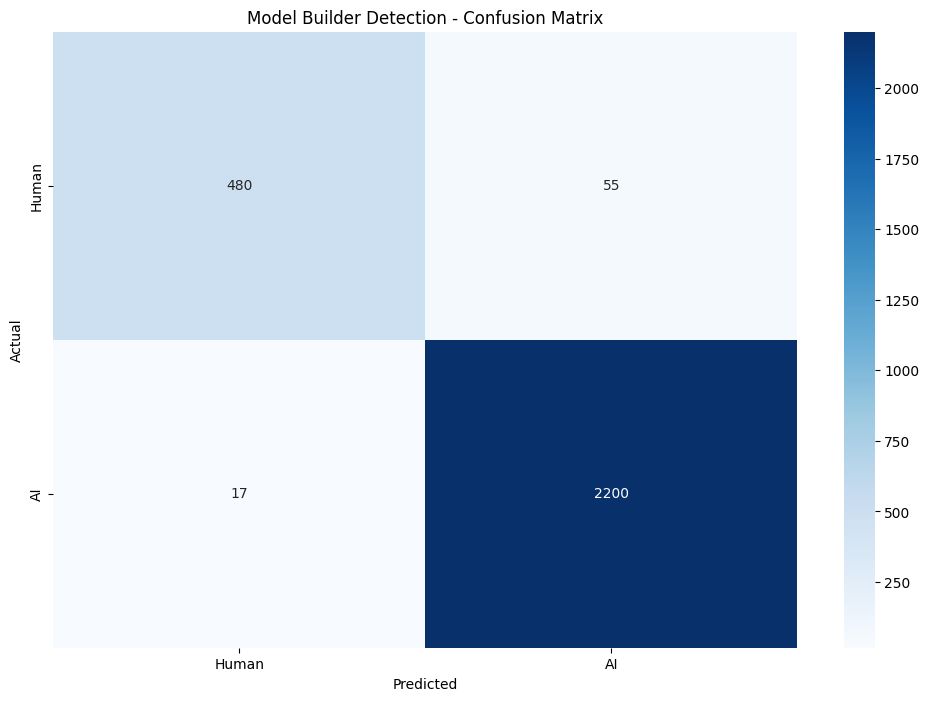

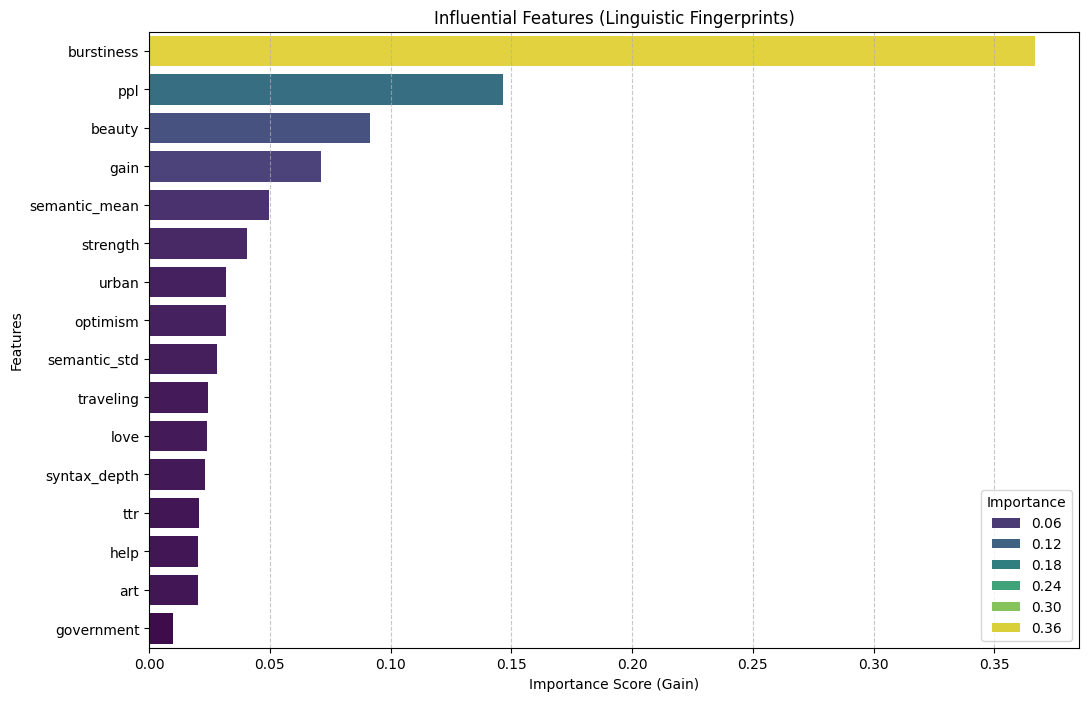

In [ ]:
print("Long Texts Evaluation:")
evaluate_model(
    df_long.drop(columns=['Text', 'Writer','is_AI']),
    z_test_series.loc[df_long.index],
    xgb_is_ai_model,
    ['Human', 'AI']
)